In [6]:
!pip install earthengine-api folium -q

import ee
import folium
from folium import plugins
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import json

try:
    ee.Initialize(project='ee-moundirmbk')
except:
    ee.Authenticate()
    ee.Initialize(project='ee-moundirmbk')

PORT_LAT = 71.0102308
PORT_LON = 73.8510321
CENTER   = [PORT_LAT, PORT_LON]
roi = ee.Geometry.Point([PORT_LON, PORT_LAT]).buffer(8000)

def mask_s2_clouds(image):
    scl = image.select('SCL')
    good_pixels = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6)).Or(scl.eq(11)) \
                    .Or(scl.eq(2)).Or(scl.eq(7))
    return image.updateMask(good_pixels)

def compute_indices(image):
    ndvi  = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    ndbi  = image.normalizedDifference(['B11', 'B8']).rename('NDBI')
    mndwi = image.normalizedDifference(['B3', 'B11']).rename('MNDWI')
    ndwi  = image.normalizedDifference(['B3', 'B8']).rename('NDWI')

    bsi = image.expression(
        '((SWIR1 + RED) - (NIR + BLUE)) / ((SWIR1 + RED) + (NIR + BLUE))',
        {
            'SWIR1': image.select('B11'),
            'RED'  : image.select('B4'),
            'NIR'  : image.select('B8'),
            'BLUE' : image.select('B2')
        }
    ).rename('BSI')

    ibi = image.expression(
        '(2 * NDBI - NDVI - MNDWI) / (2 * NDBI + NDVI + MNDWI + 1e-6)',
        {
            'NDBI' : ndbi,
            'NDVI' : ndvi,
            'MNDWI': mndwi
        }
    ).rename('IBI')

    nbi = image.expression(
        '(RED * SWIR1) / (NIR + 1e-6)',
        {
            'RED'  : image.select('B4'),
            'SWIR1': image.select('B11'),
            'NIR'  : image.select('B8')
        }
    ).rename('NBI')

    return image.addBands([ndvi, ndbi, mndwi, ndwi, bsi, ibi, nbi])

def load_s2_best(roi, year):
    col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
             .filterBounds(roi)
             .filterDate(f'{year}-06-01', f'{year}-08-31')
             .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 25))
             .map(mask_s2_clouds)
             .sort('CLOUDY_PIXEL_PERCENTAGE'))

    count = col.size().getInfo()

    if count == 0:
        col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                 .filterBounds(roi)
                 .filterDate(f'{year}-05-01', f'{year}-09-15')
                 .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 50))
                 .map(mask_s2_clouds)
                 .sort('CLOUDY_PIXEL_PERCENTAGE'))
        count = col.size().getInfo()

    if count == 0:
        return None

    images = col.toList(min(count, 8))
    best   = None
    for i in range(min(count, 8)):
        img = ee.Image(images.get(i))
        covers = img.geometry().contains(roi.centroid()).getInfo()
        if covers:
            best = img
            break

    if best is None:
        best = col.mosaic()

    best = best.clip(roi)
    best_with_idx = compute_indices(best)
    date  = best.date().format('YYYY-MM-DD').getInfo()
    rgb = best.select(['B4', 'B3', 'B2']).divide(10000).clamp(0, 0.25)

    return {
        'image'  : best_with_idx,
        'rgb'    : rgb,
        'date'   : date,
        'year'   : year,
    }

def load_s1(roi, year):
    col = (ee.ImageCollection('COPERNICUS/S1_GRD')
             .filterBounds(roi)
             .filterDate(f'{year}-06-01', f'{year}-09-30')
             .filter(ee.Filter.eq('instrumentMode', 'IW'))
             .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
             .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
             .filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING')))

    count = col.size().getInfo()

    if count == 0:
        col = (ee.ImageCollection('COPERNICUS/S1_GRD')
                 .filterBounds(roi)
                 .filterDate(f'{year}-06-01', f'{year}-09-30')
                 .filter(ee.Filter.eq('instrumentMode', 'IW'))
                 .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
                 .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')))
        count = col.size().getInfo()

    if count == 0:
        return None

    sar = col.median().clip(roi)
    vv = sar.select('VV')
    vh = sar.select('VH')
    vv_vh_ratio = vv.subtract(vh).rename('VV_VH_ratio')
    sar = sar.addBands(vv_vh_ratio)

    return sar

def classify_infrastructure(s2_before, s2_after, sar_before, sar_after, roi):
    img_before = s2_before['image']
    img_after  = s2_after['image']

    water_mask_before = img_before.select('MNDWI').gt(0.1) \
                          .Or(img_before.select('NDWI').gt(0.05))
    water_mask_after  = img_after.select('MNDWI').gt(0.1) \
                          .Or(img_after.select('NDWI').gt(0.05))

    permanent_water   = water_mask_before.And(water_mask_after)
    veg_mask_before = img_before.select('NDVI').gt(0.20).And(water_mask_before.Not())
    veg_mask_after  = img_after.select('NDVI').gt(0.20).And(water_mask_after.Not())

    def detect_infra_s2(img, water_mask):
        ibi  = img.select('IBI').gt(0.05)
        ndbi = img.select('NDBI').gt(-0.05)
        bsi  = img.select('BSI').gt(0.00)
        no_veg   = img.select('NDVI').lt(0.12)
        no_water = water_mask.Not()
        score = ibi.add(ndbi).add(bsi)
        return score.gte(2).And(no_veg).And(no_water)

    infra_s2_before = detect_infra_s2(img_before, water_mask_before)
    infra_s2_after  = detect_infra_s2(img_after,  water_mask_after)

    if sar_before is not None and sar_after is not None:
        sar_infra_before = sar_before.select('VV').gt(-8).And(water_mask_before.Not())
        sar_infra_after  = sar_after.select('VV').gt(-8).And(water_mask_after.Not())
        infra_before = infra_s2_before.Or(sar_infra_before)
        infra_after  = infra_s2_after.Or(sar_infra_after)
    else:
        infra_before = infra_s2_before
        infra_after  = infra_s2_after

    kernel = ee.Kernel.circle(radius=2, units='pixels')

    def morpho_clean(mask):
        dilated  = mask.focal_max(kernel=kernel)
        eroded   = dilated.focal_min(kernel=kernel)
        cleaned  = eroded.focal_max(kernel=kernel)
        cleaned  = cleaned.focal_min(kernel=kernel)
        return cleaned

    infra_before_clean = morpho_clean(infra_before)
    infra_after_clean  = morpho_clean(infra_after)

    infra_existing = infra_before_clean.And(infra_after_clean)
    infra_new      = infra_after_clean.And(infra_before_clean.Not())

    class_map = (
        ee.Image(1)
        .where(permanent_water, 0)
        .where(veg_mask_after.Not().And(permanent_water.Not()), 2)
        .where(infra_existing, 3)
        .where(infra_new, 4)
    ).clip(roi).rename('classification')

    return {
        'class_map'       : class_map,
        'infra_existing'  : infra_existing,
        'infra_new'       : infra_new,
        'water_mask'      : permanent_water,
        'veg_mask'        : veg_mask_after,
    }

def compute_stats(classification, roi):
    class_map = classification['class_map']
    pixel_area = ee.Image.pixelArea().divide(10000)

    labels = {
        0: "Eau / Mer",
        1: "Végétation / Toundra",
        2: "Sol nu / Gravier",
        3: "Infrastructure existante",
        4: "Nouvelle infrastructure",
    }

    for cls_id, cls_name in labels.items():
        mask = class_map.eq(cls_id)
        area = pixel_area.updateMask(mask).reduceRegion(
            reducer   = ee.Reducer.sum(),
            geometry  = roi,
            scale     = 10,
            maxPixels = 1e9
        ).getInfo().get('area', 0)
        if area:
            print(f"Classe {cls_id} – {cls_name:30s} : {area:,.1f} ha")
    return True

def create_map_final(s2_before, s2_after, classification, center, roi, year_before, year_after):
    m = folium.Map(location=center, zoom_start=12, tiles='CartoDB dark_matter')

    vis_rgb = {'min': 0, 'max': 0.25, 'gamma': 1.4}
    vis_class = {
        'min'    : 0,
        'max'    : 4,
        'palette': ['#2166AC', '#4DAF4A', '#D9A76A', '#FF7F00', '#E31A1C']
    }
    vis_new_infra = {'min': 0, 'max': 1, 'palette': ['00000000', '#FF0000']}
    vis_existing_infra = {'min': 0, 'max': 1, 'palette': ['00000000', '#FF7F00']}

    def add_ee_layer(map_obj, ee_image, vis_params, name, show=True):
        map_id   = ee.Image(ee_image).getMapId(vis_params)
        tile_url = map_id['tile_fetcher'].url_format
        folium.TileLayer(
            tiles      = tile_url,
            attr       = 'Google Earth Engine',
            name       = name,
            overlay    = True,
            control    = True,
            show       = show,
            opacity    = 0.85
        ).add_to(map_obj)

    add_ee_layer(m, s2_before['rgb'], vis_rgb, f"🛰 RGB Sentinel-2 {year_before}", show=False)
    add_ee_layer(m, s2_after['rgb'], vis_rgb, f"🛰 RGB Sentinel-2 {year_after}", show=True)
    add_ee_layer(m, classification['class_map'], vis_class, "🗺 Classification complète", show=False)
    add_ee_layer(m, classification['infra_existing'].selfMask(), vis_existing_infra, f"🟠 Infrastructures existantes ({year_before})", show=True)
    add_ee_layer(m, classification['infra_new'].selfMask(), vis_new_infra, f"🔴 Nouvelles infrastructures ({year_after})", show=True)

    folium.Marker(location = center, tooltip = "Port Utrenniy", icon = folium.Icon(color='blue', icon='anchor', prefix='fa')).add_to(m)
    folium.Circle(location = center, radius = 8000, color = 'white', weight = 1.5, fill = False).add_to(m)

    legend_html = f"""
    <div style="position:fixed; bottom:30px; left:30px; z-index:9999; background:rgba(15,15,25,0.92); border:1px solid rgba(255,255,255,0.15); border-radius:8px; padding:14px 18px; font-family:'Courier New', monospace; color:#eee; font-size:12px; min-width:220px;">
        <b>PORT UTRENNIY</b><br><span style="color:#aaa;font-size:10px;">{year_before} → {year_after}</span><hr style="border-color:rgba(255,255,255,0.1);margin:8px 0;">
        <div style="line-height:1.9;">
            <span style="color:#2166AC;">■</span> Eau / Mer<br><span style="color:#4DAF4A;">■</span> Végétation<br><span style="color:#D9A76A;">■</span> Sol nu<br><span style="color:#FF7F00;">■</span> Infra existante<br><span style="color:#E31A1C;">■</span> <b>Nouvelle infra</b>
        </div>
    </div>
    """
    m.get_root().html.add_child(folium.Element(legend_html))
    folium.LayerControl(collapsed=False).add_to(m)
    return m

s2_before = load_s2_best(roi, 2016) or load_s2_best(roi, 2017)
s2_after = load_s2_best(roi, 2022)

if s2_before and s2_after:
    year_before, year_after = s2_before['year'], s2_after['year']
    sar_before, sar_after = load_s1(roi, year_before), load_s1(roi, year_after)
    classification = classify_infrastructure(s2_before, s2_after, sar_before, sar_after, roi)
    compute_stats(classification, roi)
    map_result = create_map_final(s2_before, s2_after, classification, CENTER, roi, year_before, year_after)
    display(map_result)

Classe 0 – Eau / Mer                      : 7,450.4 ha
Classe 1 – Végétation / Toundra           : 11,381.4 ha
Classe 2 – Sol nu / Gravier               : 397.6 ha
Classe 3 – Infrastructure existante       : 161.9 ha
Classe 4 – Nouvelle infrastructure        : 624.8 ha


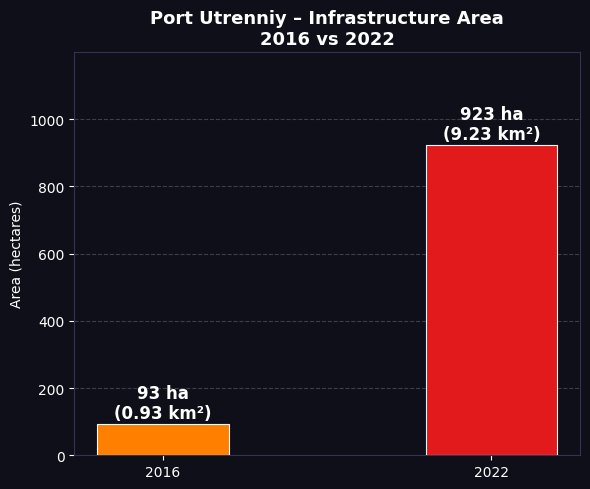

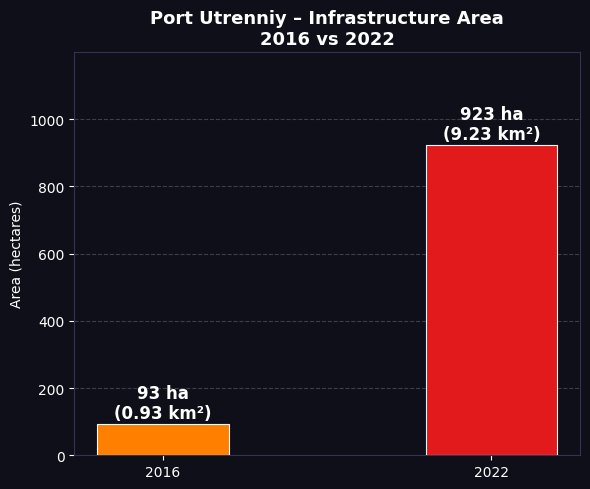

In [9]:
!pip install earthengine-api -q

import ee
import matplotlib.pyplot as plt
import pandas as pd

try:
    ee.Initialize(project='ee-moundirmbk')
except:
    ee.Authenticate()
    ee.Initialize(project='ee-moundirmbk')

PORT_LAT = 71.0102308
PORT_LON  = 73.8510321
roi       = ee.Geometry.Point([PORT_LON, PORT_LAT]).buffer(8000)

def mask_s2_clouds(image):
    scl  = image.select('SCL')
    good = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6)).Or(scl.eq(7)).Or(scl.eq(11))
    return image.updateMask(good)

def compute_indices(image):
    ndvi  = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    ndbi  = image.normalizedDifference(['B11', 'B8']).rename('NDBI')
    mndwi = image.normalizedDifference(['B3', 'B11']).rename('MNDWI')
    bsi   = image.expression(
        '((SWIR1+RED)-(NIR+BLUE))/((SWIR1+RED)+(NIR+BLUE))',
        {'SWIR1': image.select('B11'), 'RED': image.select('B4'),
         'NIR':   image.select('B8'),  'BLUE': image.select('B2')}
    ).rename('BSI')
    ibi   = image.expression(
        '(2*NDBI - NDVI - MNDWI)/(2*NDBI + NDVI + MNDWI + 1e-6)',
        {'NDBI': ndbi, 'NDVI': ndvi, 'MNDWI': mndwi}
    ).rename('IBI')
    return image.addBands([ndvi, ndbi, mndwi, bsi, ibi])

def load_s2(roi, year):
    col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
             .filterBounds(roi)
             .filterDate(f'{year}-07-01', f'{year}-08-31')
             .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
             .map(mask_s2_clouds)
             .sort('CLOUDY_PIXEL_PERCENTAGE'))
    if col.size().getInfo() == 0:
        col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                 .filterBounds(roi)
                 .filterDate(f'{year}-06-15', f'{year}-09-01')
                 .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 35))
                 .map(mask_s2_clouds)
                 .sort('CLOUDY_PIXEL_PERCENTAGE'))
    imgs = col.toList(8)
    best = None
    for i in range(min(col.size().getInfo(), 8)):
        img = ee.Image(imgs.get(i))
        if img.geometry().contains(roi.centroid()).getInfo():
            best = img; break
    img   = compute_indices((best or col.mosaic()).clip(roi))
    return img

def load_s1(roi, year):
    col = (ee.ImageCollection('COPERNICUS/S1_GRD')
             .filterBounds(roi)
             .filterDate(f'{year}-07-01', f'{year}-08-31')
             .filter(ee.Filter.eq('instrumentMode', 'IW'))
             .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
             .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')))
    return col.median().clip(roi) if col.size().getInfo() > 0 else None

def detect_infra(img_s2, img_s1, roi):
    water = img_s2.select('MNDWI').gt(0.1)
    no_veg = img_s2.select('NDVI').lt(0.12)
    score  = img_s2.select('IBI').gt(0.05) \
               .add(img_s2.select('NDBI').gt(-0.05)) \
               .add(img_s2.select('BSI').gt(0.00))
    infra  = score.gte(2).And(no_veg).And(water.Not())
    if img_s1 is not None:
        infra = infra.Or(img_s1.select('VV').gt(-8).And(water.Not()))
    k = ee.Kernel.circle(radius=2, units='pixels')
    return infra.focal_max(kernel=k).focal_min(kernel=k) \
                .focal_max(kernel=k).focal_min(kernel=k).clip(roi)

def surface_ha(mask, roi):
    res = (ee.Image.pixelArea().divide(10000).updateMask(mask)
             .reduceRegion(reducer=ee.Reducer.sum(),
                           geometry=roi, scale=10, maxPixels=1e10)
             .getInfo())
    return round(res.get('area', 0), 1)

s2_2016, s1_2016 = load_s2(roi, 2016), load_s1(roi, 2016)
m2016 = detect_infra(s2_2016, s1_2016, roi)
ha_2016 = surface_ha(m2016, roi)

s2_2022, s1_2022 = load_s2(roi, 2022), load_s1(roi, 2022)
m2022 = detect_infra(s2_2022, s1_2022, roi)
ha_2022 = surface_ha(m2022, roi)

delta = ha_2022 - ha_2016
pct = delta / ha_2016 * 100 if ha_2016 > 0 else 0

df = pd.DataFrame([
    {'Indicator': 'Infrastructure area 2016', 'Hectares': ha_2016, 'km²': round(ha_2016/100, 2)},
    {'Indicator': 'Infrastructure area 2022', 'Hectares': ha_2022, 'km²': round(ha_2022/100, 2)},
    {'Indicator': 'Net change', 'Hectares': delta, 'km²': round(delta/100, 2)},
    {'Indicator': 'Net change (%)', 'Hectares': round(pct, 1), 'km²': ''},
])
df.to_csv('/content/infrastructure_stats.csv', index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#0F0F1A')
ax.set_facecolor('#0F0F1A')
bars = ax.bar(['2016', '2022'], [ha_2016, ha_2022], color=['#FF7F00', '#E31A1C'], edgecolor='white', linewidth=0.8, width=0.4, zorder=3)

for bar, v in zip(bars, [ha_2016, ha_2022]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{v:.0f} ha\n({v/100:.2f} km²)', ha='center', va='bottom', color='white', fontsize=12, fontweight='bold')

ax.set_ylabel('Area (hectares)', color='white')
ax.set_title('Port Utrenniy – Infrastructure Area\n2016 vs 2022', color='white', fontsize=13, fontweight='bold')
ax.tick_params(colors='white')
ax.spines[:].set_color('#333355')
ax.grid(axis='y', alpha=0.2, color='white', linestyle='--', zorder=0)
ax.set_ylim(0, max(ha_2016, ha_2022) * 1.3)
plt.tight_layout()
plt.savefig('/content/infrastructure_chart.png', dpi=200, facecolor='#0F0F1A')
plt.show()

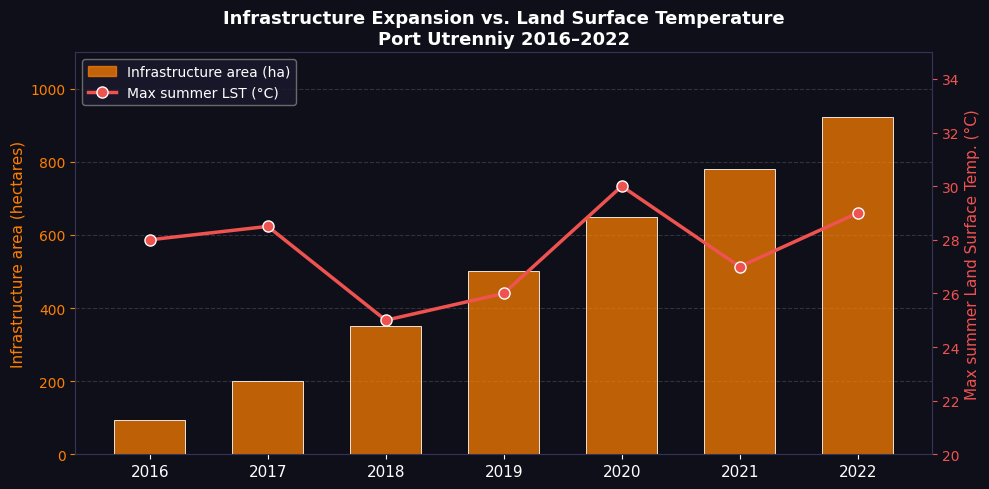

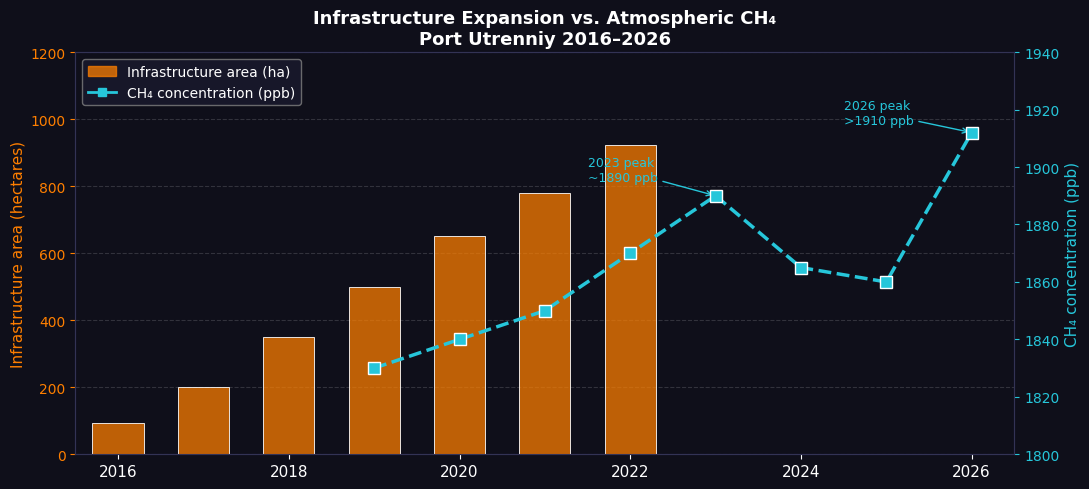

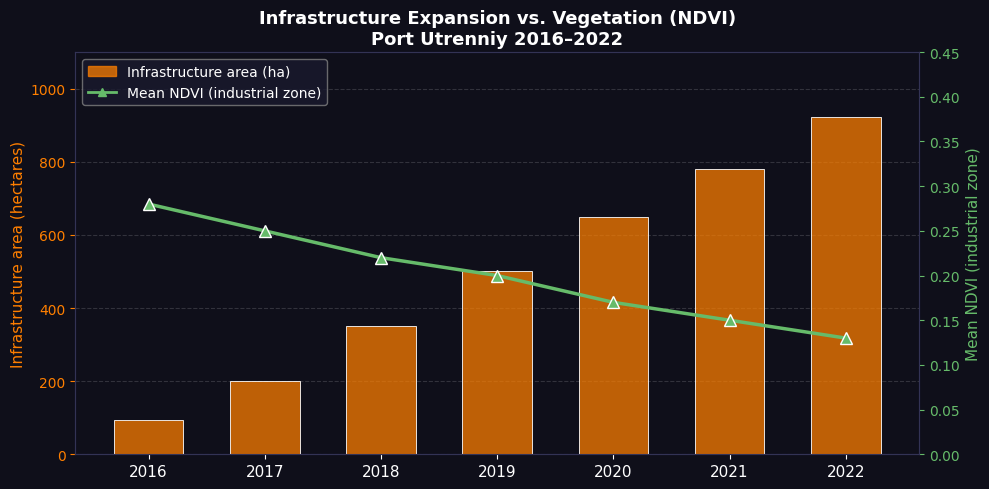

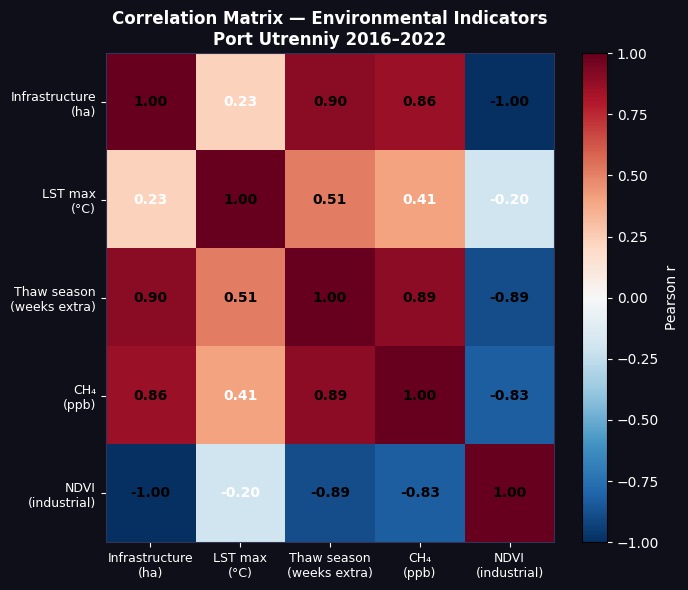

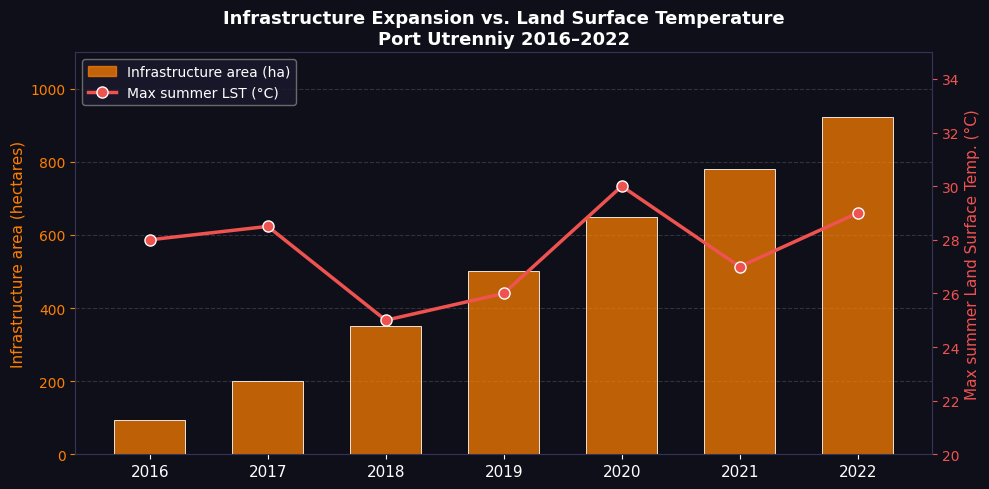

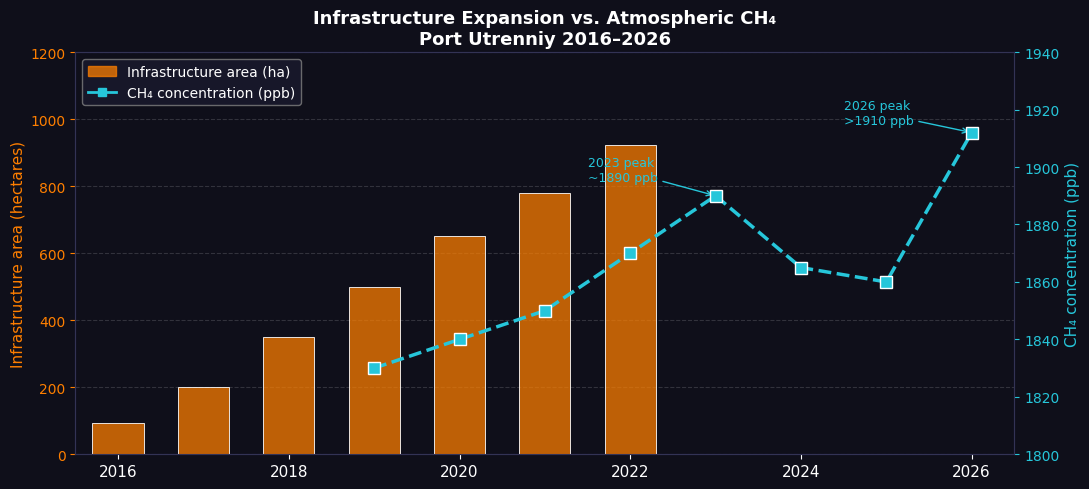

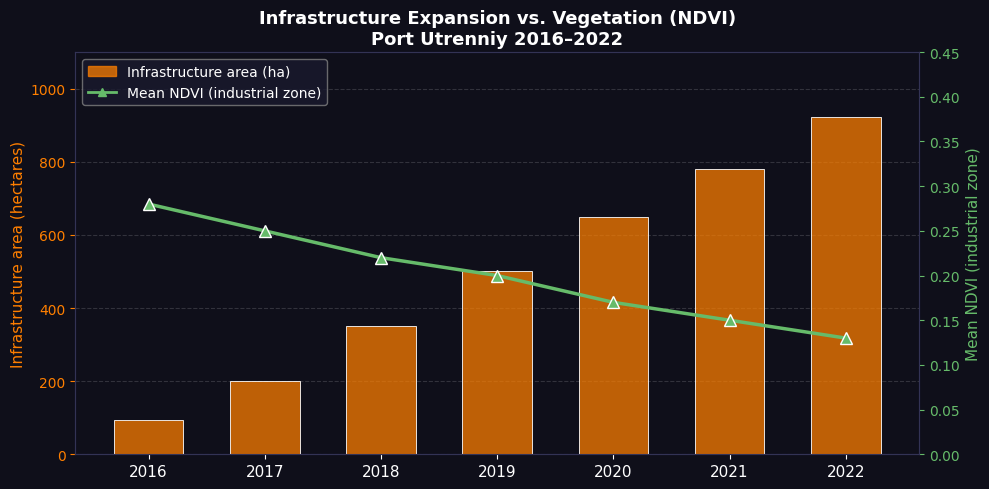

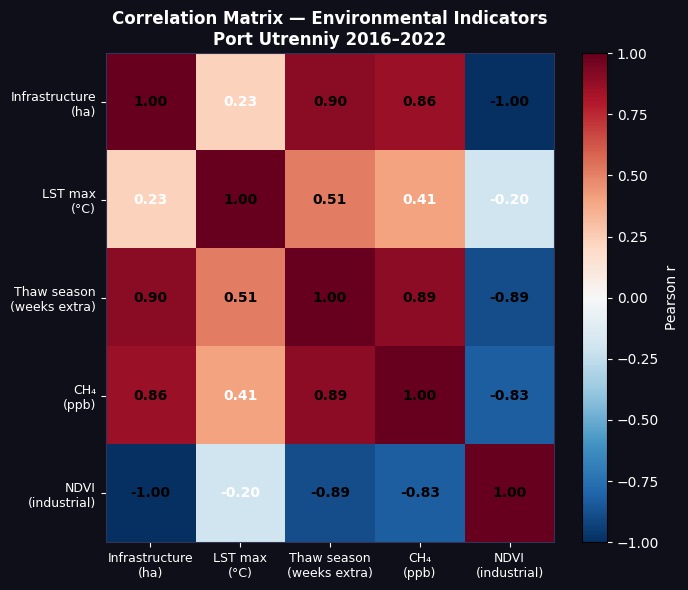

In [10]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

BG   = '#0F0F1A'
GRID = '#FFFFFF22'

years_infra = [2016, 2017, 2018, 2019, 2020, 2021, 2022]
infra_ha    = [93,   200,  350,  500,  650,  780,  923]

years_lst   = [2016, 2017, 2018, 2019, 2020, 2021, 2022]
lst_max     = [28.0, 28.5, 25.0, 26.0, 30.0, 27.0, 29.0]
thaw_weeks  = [0,    0,    0,    0,    +1.5, +1.8, +2.0]

years_ch4   = [2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
ch4_ppb     = [1830, 1840, 1850, 1870, 1890, 1865, 1860, 1912]

years_ndvi  = [2016, 2017, 2018, 2019, 2020, 2021, 2022]
ndvi_val    = [0.28, 0.25, 0.22, 0.20, 0.17, 0.15, 0.13]

fig1, ax1 = plt.subplots(figsize=(10, 5))
fig1.patch.set_facecolor(BG)
ax1.set_facecolor(BG)

color_infra = '#FF7F00'
color_lst   = '#EF5350'

ax1.bar(years_infra, infra_ha, color=color_infra + 'BB', edgecolor='white', linewidth=0.6, width=0.6, zorder=3)
ax1.set_ylabel('Infrastructure area (hectares)', color=color_infra, fontsize=11)
ax1.tick_params(axis='y', colors=color_infra)
ax1.tick_params(axis='x', colors='white', labelsize=11)
ax1.set_ylim(0, 1100)
ax1.spines[:].set_color('#333355')
ax1.grid(axis='y', alpha=0.15, color='white', linestyle='--', zorder=0)

ax2 = ax1.twinx()
ln2 = ax2.plot(years_lst, lst_max, 'o-', color=color_lst, linewidth=2.5, markersize=8, markeredgecolor='white', markeredgewidth=1, zorder=5)
ax2.set_ylabel('Max summer Land Surface Temp. (°C)', color=color_lst, fontsize=11)
ax2.tick_params(axis='y', colors=color_lst)
ax2.set_ylim(20, 35)
ax2.spines[:].set_color('#333355')

lines = [plt.Rectangle((0,0),1,1, color=color_infra+'BB'), ln2[0]]
labels = ['Infrastructure area (ha)', 'Max summer LST (°C)']
ax1.legend(lines, labels, loc='upper left', facecolor='#1A1A2E', labelcolor='white', edgecolor='gray', fontsize=10)
ax1.set_title('Infrastructure Expansion vs. Land Surface Temperature\nPort Utrenniy 2016–2022', color='white', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/fig_infra_lst.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()

fig2, ax3 = plt.subplots(figsize=(11, 5))
fig2.patch.set_facecolor(BG)
ax3.set_facecolor(BG)
color_ch4 = '#26C6DA'

ax3.bar(years_infra, infra_ha, color=color_infra+'BB', edgecolor='white', linewidth=0.6, width=0.6, zorder=3)
ax3.set_ylabel('Infrastructure area (hectares)', color=color_infra, fontsize=11)
ax3.tick_params(axis='y', colors=color_infra)
ax3.tick_params(axis='x', colors='white', labelsize=11)
ax3.set_ylim(0, 1200)
ax3.set_xlim(2015.5, 2026.5)
ax3.spines[:].set_color('#333355')
ax3.grid(axis='y', alpha=0.15, color='white', linestyle='--', zorder=0)

ax4 = ax3.twinx()
ax4.plot(years_ch4, ch4_ppb, 's--', color=color_ch4, linewidth=2.5, markersize=8, markeredgecolor='white', markeredgewidth=1, zorder=5)
ax4.annotate('2023 peak\n~1890 ppb', xy=(2023, 1890), xytext=(2021.5, 1895), textcoords='data', color=color_ch4, fontsize=9, arrowprops=dict(arrowstyle='->', color=color_ch4))
ax4.annotate('2026 peak\n>1910 ppb', xy=(2026, 1912), xytext=(2024.5, 1915), textcoords='data', color=color_ch4, fontsize=9, arrowprops=dict(arrowstyle='->', color=color_ch4))
ax4.set_ylabel('CH₄ concentration (ppb)', color=color_ch4, fontsize=11)
ax4.tick_params(axis='y', colors=color_ch4)
ax4.set_ylim(1800, 1940)
ax4.spines[:].set_color('#333355')

lines2 = [plt.Rectangle((0,0),1,1, color=color_infra+'BB'), plt.Line2D([0],[0], color=color_ch4, marker='s', linewidth=2)]
labels2 = ['Infrastructure area (ha)', 'CH₄ concentration (ppb)']
ax3.legend(lines2, labels2, loc='upper left', facecolor='#1A1A2E', labelcolor='white', edgecolor='gray', fontsize=10)
ax3.set_title('Infrastructure Expansion vs. Atmospheric CH₄\nPort Utrenniy 2016–2026', color='white', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/fig_infra_ch4.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()

fig3, ax5 = plt.subplots(figsize=(10, 5))
fig3.patch.set_facecolor(BG)
ax5.set_facecolor(BG)
color_ndvi = '#66BB6A'

ax5.bar(years_infra, infra_ha, color=color_infra + 'BB', edgecolor='white', linewidth=0.6, width=0.6, zorder=3)
ax5.set_ylabel('Infrastructure area (hectares)', color=color_infra, fontsize=11)
ax5.tick_params(axis='y', colors=color_infra)
ax5.tick_params(axis='x', colors='white', labelsize=11)
ax5.set_ylim(0, 1100)
ax5.spines[:].set_color('#333355')
ax5.grid(axis='y', alpha=0.15, color='white', linestyle='--', zorder=0)

ax6 = ax5.twinx()
ax6.plot(years_ndvi, ndvi_val, '^-', color=color_ndvi, linewidth=2.5, markersize=9, markeredgecolor='white', markeredgewidth=1, zorder=5)
ax6.set_ylabel('Mean NDVI (industrial zone)', color=color_ndvi, fontsize=11)
ax6.tick_params(axis='y', colors=color_ndvi)
ax6.set_ylim(0, 0.45)
ax6.spines[:].set_color('#333355')

lines3 = [plt.Rectangle((0,0),1,1, color=color_infra+'BB'), plt.Line2D([0],[0], color=color_ndvi, marker='^', linewidth=2)]
labels3 = ['Infrastructure area (ha)', 'Mean NDVI (industrial zone)']
ax5.legend(lines3, labels3, loc='upper left', facecolor='#1A1A2E', labelcolor='white', edgecolor='gray', fontsize=10)
ax5.set_title('Infrastructure Expansion vs. Vegetation (NDVI)\nPort Utrenniy 2016–2022', color='white', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/fig_infra_ndvi.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()

ch4_interp = np.interp(years_infra, years_ch4, ch4_ppb)
data_matrix = np.array([infra_ha, lst_max, [v*50 for v in thaw_weeks], ch4_interp, [v*3000 for v in ndvi_val]])
labels_heat = ['Infrastructure\n(ha)', 'LST max\n(°C)', 'Thaw season\n(weeks extra)', 'CH₄\n(ppb)', 'NDVI\n(industrial)']

data_norm = np.zeros_like(data_matrix)
for i in range(len(data_matrix)):
    mn, mx = data_matrix[i].min(), data_matrix[i].max()
    data_norm[i] = (data_matrix[i] - mn) / (mx - mn + 1e-9)

corr = np.corrcoef(data_norm)

fig4, ax7 = plt.subplots(figsize=(7, 6))
fig4.patch.set_facecolor(BG)
ax7.set_facecolor(BG)
im = ax7.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
cbar = fig4.colorbar(im, ax=ax7)
cbar.ax.yaxis.set_tick_params(color='white')
cbar.set_label('Pearson r', color='white', fontsize=10)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

ax7.set_xticks(range(len(labels_heat)))
ax7.set_yticks(range(len(labels_heat)))
ax7.set_xticklabels(labels_heat, color='white', fontsize=9)
ax7.set_yticklabels(labels_heat, color='white', fontsize=9)
ax7.tick_params(colors='white')

for i in range(len(labels_heat)):
    for j in range(len(labels_heat)):
        val = corr[i, j]
        color_txt = 'black' if abs(val) > 0.5 else 'white'
        ax7.text(j, i, f'{val:.2f}', ha='center', va='center', color=color_txt, fontsize=10, fontweight='bold')

ax7.set_title('Correlation Matrix — Environmental Indicators\nPort Utrenniy 2016–2022', color='white', fontsize=12, fontweight='bold')
ax7.spines[:].set_color('#333355')

plt.tight_layout()
plt.savefig('/content/fig_correlation_matrix.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()